# Distinction Task

**1. Melbourne Housing Data acquisition: choose the top three suburbs that you want to live in Melbourne, leverage realestate.com.au to automatically or manually collect at least 150 housing data points (at least 50 for each suburb). For each housing data point, prepare as many features as you can, example features are property type, location, number of bedrooms/bathrooms, land size, sale date, etc. The target variable is sold price.**

Firstly, I used web scrapper chrome extension and saved the inputs in data_housing.csv file.

In [1]:
import pandas as pd

df = pd.read_csv("house_data.csv") 
# Save one df for later
df_save = df.copy(deep=True)

features_df=df.columns
df.head()

,Date,Carspaces,Bathrooms,Type,Bedrooms,Address,Price,Name
0,NaN,2.0,1.0,Unit,2,"4 Alison Court, Carrum","$600,000 - $650,000",Troy Pullar
1,Inspection Sun 21 Sep,1.0,2.0,House,2,"5 Bronte Avenue, Burwood","$900,000",NaN
2,Inspection Fri 19 Sep,2.0,2.0,House,4,"16 Victor Avenue, Kew","$2,750,000 - 2,850,000",Ripple Wu
3,Inspection Sat 20 Sep,4.0,2.0,House,3,"101 Sackville Street, Kew","$3,200,000 - $3,500,000",Perry Zhou
4,Inspection Sat 20 Sep,2.0,4.0,House,5,"8 Monterey Close, Kew","$3,500,000 - $3,800,000",Samuel Jay


In [2]:
print(features_df)

Index(['Date', 'Carspaces', 'Bathrooms', 'Type', 'Bedrooms', 'Address',
       'Price', 'Name'],
      dtype='object')


In [3]:
# As Suburb is written after , in address. Let's extract and make a different column
df['Suburb'] = df['Address'].apply(lambda x: x.split(',')[-1].strip() if pd.notnull(x) else None)

print(df.head())

                    Date  Carspaces  Bathrooms   Type Bedrooms  \
0                    NaN        2.0        1.0   Unit        2   
1  Inspection Sun 21 Sep        1.0        2.0  House        2   
2  Inspection Fri 19 Sep        2.0        2.0  House        4   
3  Inspection Sat 20 Sep        4.0        2.0  House        3   
4  Inspection Sat 20 Sep        2.0        4.0  House        5   

                     Address                    Price         Name   Suburb  
0     4 Alison Court, Carrum      $600,000 - $650,000  Troy Pullar   Carrum  
1   5 Bronte Avenue, Burwood                 $900,000          NaN  Burwood  
2      16 Victor Avenue, Kew   $2,750,000 - 2,850,000    Ripple Wu      Kew  
3  101 Sackville Street, Kew  $3,200,000 - $3,500,000   Perry Zhou      Kew  
4      8 Monterey Close, Kew  $3,500,000 - $3,800,000   Samuel Jay      Kew  


In [4]:
import pandas as pd
import re
import numpy as np
# Let's clean Price value as their is range given for some values. So, we will take average of those values and also remove symbols to make it numeric.
def clean_price(value):
    if pd.isnull(value):
        return np.nan
    
    text = str(value)
    
    # Handling price ranges by taking the average
    if "-" in text:
        nums = re.findall(r'\d[\d,]*', text)
        if len(nums) == 2:
            low = int(nums[0].replace(",", ""))
            high = int(nums[1].replace(",", ""))
            return (low + high) / 2

    # Handling single price by removing the symbols like , and $
    nums = re.findall(r'\d[\d,]*', text)
    if nums:
        return int(nums[0].replace(",", ""))

    return np.nan

# clean each price by applying clean_price() function to each price value
df['Price'] = df['Price'].apply(clean_price)

print(df['Price'].head(10))


0     625000.0
1     900000.0
2    2800000.0
3    3350000.0
4    3650000.0
5    1250000.0
6          NaN
7     995000.0
8          NaN
9    1450000.0
Name: Price, dtype: float64


In [5]:
# We will simply drop rows which have nan in address or price as if they are not mentioned there's no point for the sale of house
df = df.dropna(subset=['Address'])
print(df)

                      Date  Carspaces  Bathrooms       Type Bedrooms  \
0                      NaN        2.0        1.0       Unit        2   
1    Inspection Sun 21 Sep        1.0        2.0      House        2   
2    Inspection Fri 19 Sep        2.0        2.0      House        4   
3    Inspection Sat 20 Sep        4.0        2.0      House        3   
4    Inspection Sat 20 Sep        2.0        4.0      House        5   
..                     ...        ...        ...        ...      ...   
353    Inspection tomorrow        2.0        1.0       Unit        3   
354                    NaN        1.0        1.0        NaN        1   
355    Inspection tomorrow        2.0        3.0      House        3   
356    Inspection tomorrow        1.0        1.0  Apartment        3   
357  Inspection Sat 20 Sep        2.0        1.0  Apartment        2   

                           Address      Price         Name   Suburb  
0           4 Alison Court, Carrum   625000.0  Troy Pullar   Carr

In [6]:
num_cols = ['Bedrooms','Bathrooms','Carspaces','Price']
# Now, convert the each NaN value to median of the column because median is not affected by outliers.
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
# Since, address are compuslsory and we already removed the rows which don't have them
# We will handle NaN value of Type column now; and we will not use name column in model as we know it won't affect the Price
df['Type'] = df['Type'].fillna("Unknown")

In [7]:
# firstly, fill the Nan value but this will change column type to str not date

df["Date"] = df["Date"].fillna("Thu 18 Sep")
# Replace Tommorow with Date
df["Date"] = df["Date"].str.replace(r"(?i)Inspection\s*tomorrow", "Sat 20 Sep", regex=True)

# Removing inspection 
df["Date"] = df["Date"].str.replace(r"^Inspection\s*", "", regex=True)
df["Date"] = pd.to_datetime(df["Date"] + " 2025", errors="coerce", dayfirst=True)

df.head()

,Date,Carspaces,Bathrooms,Type,Bedrooms,Address,Price,Name,Suburb
0,2025-09-18,2.0,1.0,Unit,2.0,"4 Alison Court, Carrum",625000.0,Troy Pullar,Carrum
1,2025-09-21,1.0,2.0,House,2.0,"5 Bronte Avenue, Burwood",900000.0,NaN,Burwood
2,2025-09-19,2.0,2.0,House,4.0,"16 Victor Avenue, Kew",2800000.0,Ripple Wu,Kew
3,2025-09-20,4.0,2.0,House,3.0,"101 Sackville Street, Kew",3350000.0,Perry Zhou,Kew
4,2025-09-20,2.0,4.0,House,5.0,"8 Monterey Close, Kew",3650000.0,Samuel Jay,Kew


In [8]:
print(df.dtypes)
# Save this cleaned data into another Dataframe
df_cleaned = df.copy(deep=True)

Date         datetime64[ns]
Carspaces           float64
Bathrooms           float64
Type                 object
Bedrooms            float64
Address              object
Price               float64
Name                 object
Suburb               object
dtype: object


**2. Conduct data preprocessing and exploratory data analysis:**
**a. Convert categorical variables (e.g. unit/house/apartment) using one-hot encoding.**

Now, we will apply one-hot encoding to Type and Suburb column of the dataset. Since, address and Name are unique for each and they are not the reason the price will change. So, we are not using these columns in the model. 

In [9]:
cat_cols = ['Type', 'Suburb']  
df= pd.get_dummies(df, columns=cat_cols, drop_first=False)

In [10]:
# Drop address and Name as they are not needed in modelling
# For address we used suburbs so now we don't need address. And Name of the person doesn't affect anything.
df = df.drop(columns=['Address', 'Name'])
df.head(10)

,Date,Carspaces,Bathrooms,Bedrooms,Price,Type_Apartment,Type_Block of units,Type_House,Type_Residential land,Type_Retirement living,Type_Studio,Type_Townhouse,Type_Unit,Type_Unknown,Type_Villa,Suburb_Burwood,Suburb_Carrum,Suburb_Kew
0,2025-09-18,2.0,1.0,2.0,625000.0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,2025-09-21,1.0,2.0,2.0,900000.0,False,False,True,False,False,False,False,False,False,False,True,False,False
2,2025-09-19,2.0,2.0,4.0,2800000.0,False,False,True,False,False,False,False,False,False,False,False,False,True
3,2025-09-20,4.0,2.0,3.0,3350000.0,False,False,True,False,False,False,False,False,False,False,False,False,True
4,2025-09-20,2.0,4.0,5.0,3650000.0,False,False,True,False,False,False,False,False,False,False,False,False,True
5,2025-09-20,2.0,2.0,3.0,1250000.0,False,False,False,False,False,False,True,False,False,False,True,False,False
7,2025-09-20,1.0,2.0,3.0,995000.0,False,False,False,False,False,False,True,False,False,False,False,False,True
9,2025-09-20,2.0,2.0,3.0,1450000.0,False,False,False,False,False,False,True,False,False,False,False,False,True
10,2025-09-18,2.0,2.0,3.0,997500.0,False,False,False,False,False,False,True,False,False,False,False,True,False
11,2025-09-18,2.0,2.0,2.0,1050000.0,False,False,False,False,False,False,False,False,True,False,False,False,True


**b. Create new features (e.g., number of schools nearby).**

In [11]:
# Let's create new features
# One feature Suburb was already created in the first part from address column
df['Total_rooms']=df['Bedrooms']+df['Carspaces']

In [12]:
# Now, add nearby schools too but since, in real dataset nobody mentioned. we can generate value using random numbers functios of numpy.
import numpy as np
np.random.seed(100)
df['Schools'] = np.random.randint(0, 10, size=len(df))

In [13]:
# Next, we will delete Date column and create month because datetime object is not used in modelling

df["Month"] = df["Date"].dt.month

df = df.drop(columns=["Date"])
df.head()

,Carspaces,Bathrooms,Bedrooms,Price,Type_Apartment,Type_Block of units,Type_House,Type_Residential land,Type_Retirement living,Type_Studio,Type_Townhouse,Type_Unit,Type_Unknown,Type_Villa,Suburb_Burwood,Suburb_Carrum,Suburb_Kew,Total_rooms,Schools,Month
0,2.0,1.0,2.0,625000.0,False,False,False,False,False,False,False,True,False,False,False,True,False,4.0,8,9
1,1.0,2.0,2.0,900000.0,False,False,True,False,False,False,False,False,False,False,True,False,False,3.0,8,9
2,2.0,2.0,4.0,2800000.0,False,False,True,False,False,False,False,False,False,False,False,False,True,6.0,3,9
3,4.0,2.0,3.0,3350000.0,False,False,True,False,False,False,False,False,False,False,False,False,True,7.0,7,9
4,2.0,4.0,5.0,3650000.0,False,False,True,False,False,False,False,False,False,False,False,False,True,7.0,7,9


**c. Normalize or standardize numerical features.**

In [14]:
# Since, months are from 1-12 and we need to preserve their nature
df["Month_sin"] = np.sin(2 * np.pi * df["Month"]/12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"]/12)

df = df.drop(columns=["Month"])
num_scaled=['Bedrooms','Bathrooms','Carspaces','Total_rooms','Schools','Month_sin','Month_cos']
# Let's standardize each numeric column so each column have same mean and variance
# We didn't scaled price as it was response variable
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_scaled] = scaler.fit_transform(df[num_scaled])

df.head(10)

,Carspaces,Bathrooms,Bedrooms,Price,Type_Apartment,Type_Block of units,Type_House,Type_Residential land,Type_Retirement living,Type_Studio,...,Type_Unit,Type_Unknown,Type_Villa,Suburb_Burwood,Suburb_Carrum,Suburb_Kew,Total_rooms,Schools,Month_sin,Month_cos
0,0.066554,-1.042079,-0.615982,625000.0,False,False,False,False,False,False,...,True,False,False,False,True,False,-0.429758,1.390420,0.0,-2.465190e-32
1,-0.994606,-0.007212,-0.615982,900000.0,False,False,True,False,False,False,...,False,False,False,True,False,False,-0.847862,1.390420,0.0,-2.465190e-32
2,0.066554,-0.007212,0.513646,2800000.0,False,False,True,False,False,False,...,False,False,False,False,False,True,0.406449,-0.443452,0.0,-2.465190e-32
3,2.188873,-0.007212,-0.051168,3350000.0,False,False,True,False,False,False,...,False,False,False,False,False,True,0.824553,1.023646,0.0,-2.465190e-32
4,0.066554,2.062524,1.078460,3650000.0,False,False,True,False,False,False,...,False,False,False,False,False,True,0.824553,1.023646,0.0,-2.465190e-32
5,0.066554,-0.007212,-0.051168,1250000.0,False,False,False,False,False,False,...,False,False,False,True,False,False,-0.011654,-1.543775,0.0,-2.465190e-32
7,-0.994606,-0.007212,-0.051168,995000.0,False,False,False,False,False,False,...,False,False,False,False,False,True,-0.429758,-0.076678,0.0,-2.465190e-32
9,0.066554,-0.007212,-0.051168,1450000.0,False,False,False,False,False,False,...,False,False,False,False,False,True,-0.011654,-0.810226,0.0,-2.465190e-32
10,0.066554,-0.007212,-0.051168,997500.0,False,False,False,False,False,False,...,False,False,False,False,True,False,-0.011654,0.290097,0.0,-2.465190e-32
11,0.066554,-0.007212,-0.615982,1050000.0,False,False,False,False,False,False,...,False,True,False,False,False,True,-0.429758,-0.810226,0.0,-2.465190e-32


**d. Visualize housing price distributions, feature to target correlations, and outliers.**

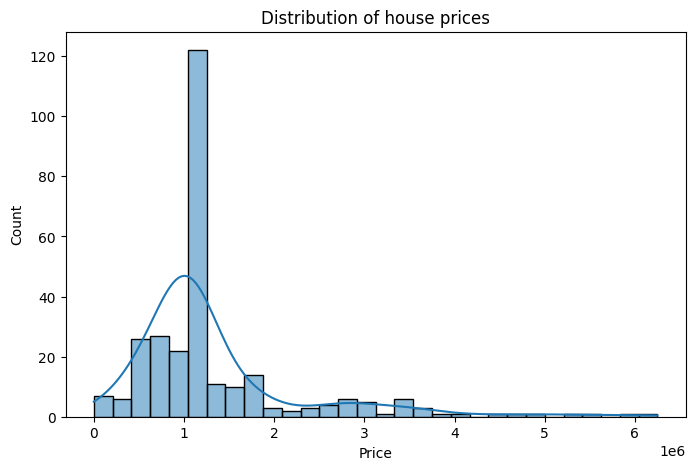

In [15]:
# First, let's visualize histogram of price using seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title("Distribution of house prices")
plt.show()

From the above graph, we can see that the Price feature is right skewed.

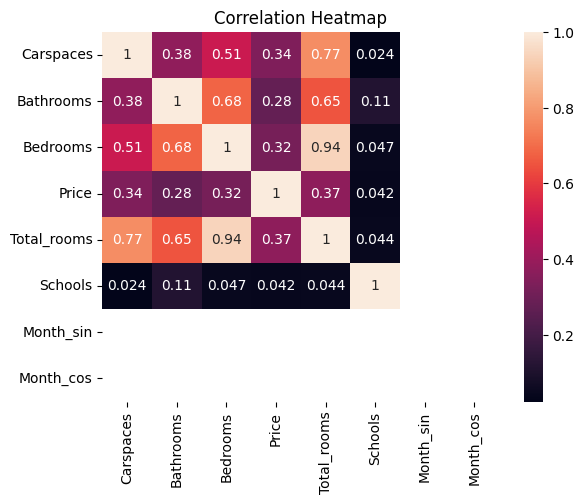

In [16]:
# Next, we need to plot heatmap to check correlation of each variables
num_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


The light color indicates the strong possitive correlation wheras the dark color either mean that weak correlation between features.

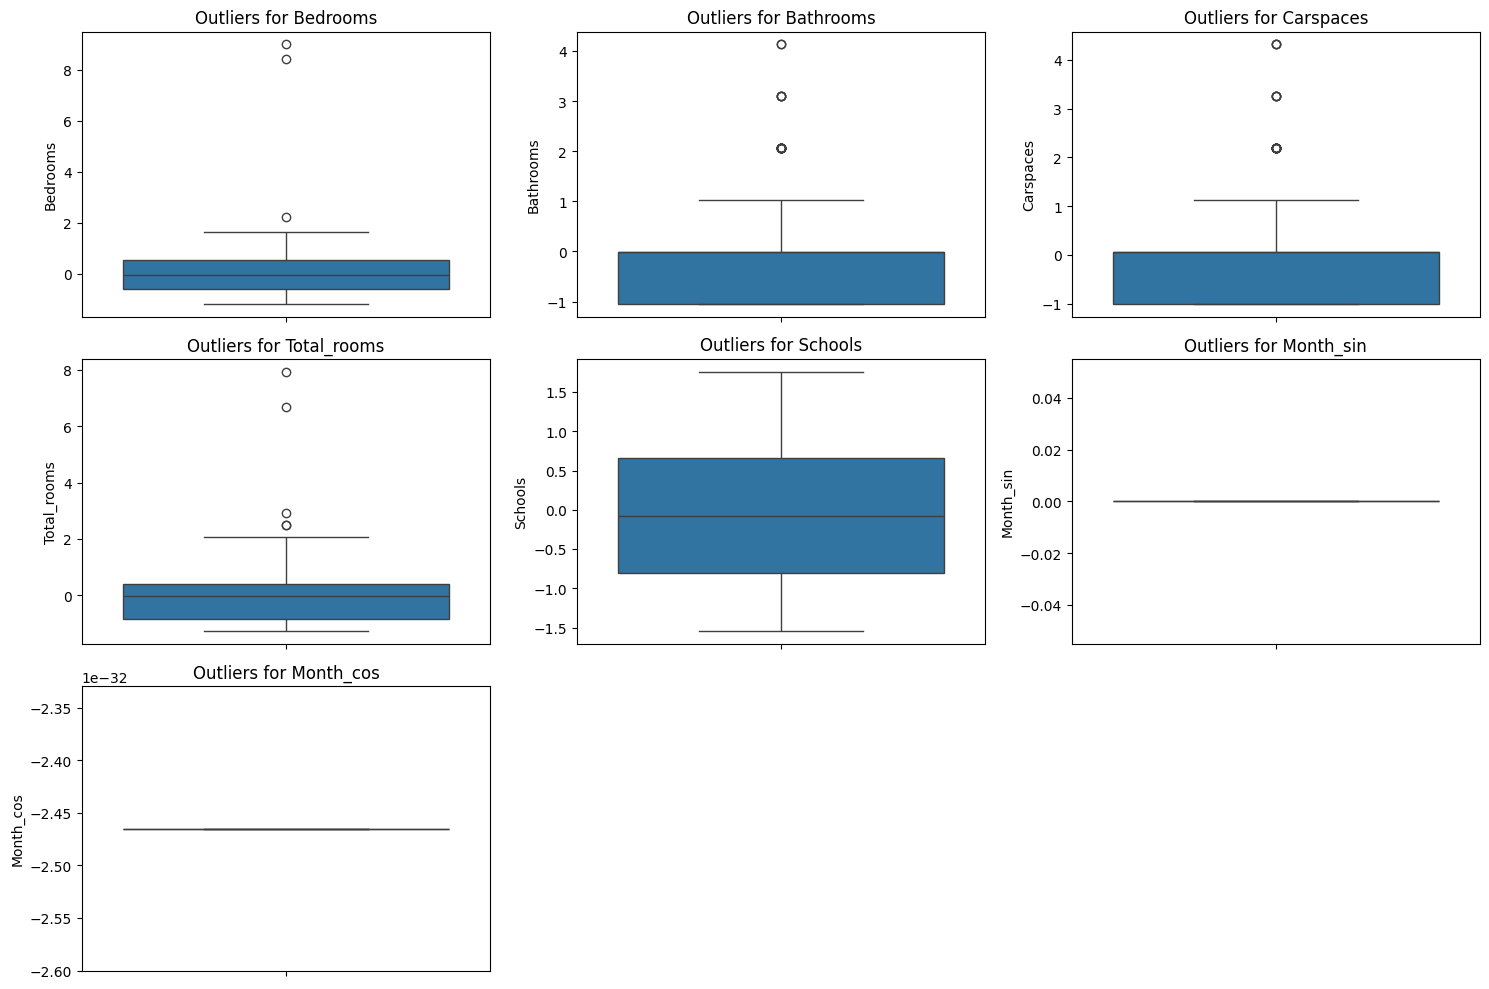

In [17]:
# Now, to check outliers we will see boxplot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
# Create plots for all numerical features in one plot using subplot()
for i, col in enumerate(num_scaled, 1):  
    plt.subplot(3, 3, i)  
    sns.boxplot(y=df[col])
    plt.title(f"Outliers for {col}")

plt.tight_layout()
plt.show()


The boxplot of Month is not visible because its median, first quantile and second quantie would be similar.

**e. Identify price trends over time across suburbs.**

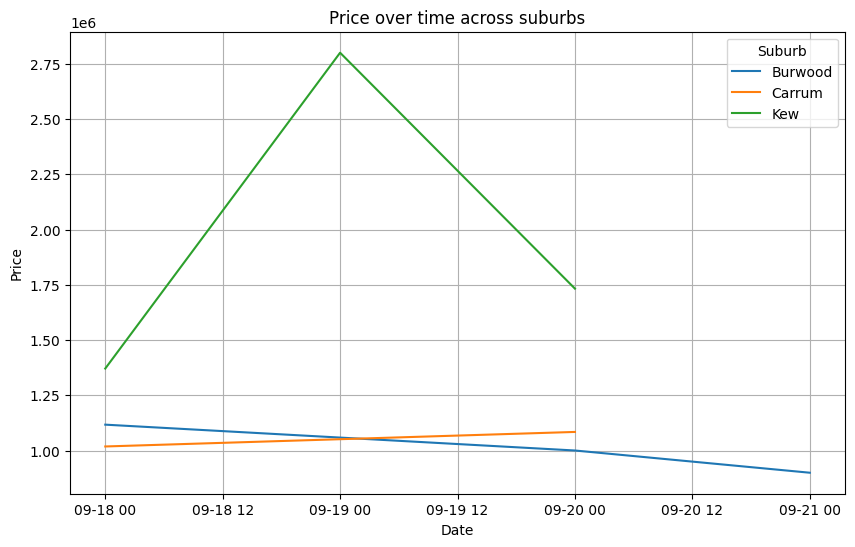

In [18]:
# Since, we scaled the Month and Suburb  So, let;s use cleaned data for this plot

trends = df_cleaned.groupby(["Suburb", "Date"])["Price"].mean().reset_index()

# Plotting graph
plt.figure(figsize=(10,6))
sns.lineplot(
    data=trends,
    x="Date",
    y="Price",
    hue="Suburb"
)
plt.title("Price over time across suburbs")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.legend(title="Suburb")
plt.show()

**3. Model development: develop at least three different regression models, use MAE, RMSE and R-squared as the evaluation metrics, use k-fold cross validation to evaluate the model performance.**

In [19]:
from sklearn.model_selection import train_test_split
# predictor variables
X = df.drop(columns=['Price']) 
#response variable
y = df['Price']                 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [20]:
#Let's develop linear regression, Random forest and gradient booster and then evaluate them
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
#let's fit the models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=100)
}
# Now, evaluate the model performance
# We will use cross-validation and split data into 5 folds
folds = KFold(n_splits=5, shuffle=True, random_state=100)
# shuffling is needed if we want to set random_state"
for name, model in models.items():
    # cross_val_score runs the model 5 times
    # Since, sklearn gives negative error values so negative
    mae = -cross_val_score(model, X, y, cv=folds, scoring='neg_mean_absolute_error').mean()
    # rmse is sqrt of mean square error
    rmse = np.sqrt(-cross_val_score(model, X, y, cv=folds, scoring='neg_mean_squared_error').mean())
    r2_val = cross_val_score(model, X, y, cv=folds, scoring='r2').mean()
    
    print(f"{name}: MAE={mae}, RMSE={rmse}, R2={r2_val}\n")

Linear Regression: MAE=575166.3275088578, RMSE=902496.0420740547, R2=0.0011008070431504536

Random Forest: MAE=549447.4573823443, RMSE=860952.0990024715, R2=0.121583478521335

Gradient Boosting: MAE=535607.5853348054, RMSE=880161.6211870568, R2=0.1035983430004798



We can interpret that Mean absolute error of gradient boosting is least but Root Mean Square Error of random forest is minimum. The linear regression didn't performed well since, we knew from graph that price trend wasn't linear. Even though R^2 is least for linear regression but the MAE and RMSE indicates worst model. Moreover, due to high RMSE of gradient boosting and low MAE it looks that the model overfitted the data. Overall, Random Forest is the best model to proceed further.

**4. Feature importance: identify which features more influence housing price, use model-specific methods (e.g., feature importance in tree-based methods) or other statistical methods (e.g., SHAP values).**

In [21]:
import matplotlib.pyplot as plt
# Fitting random forest model
RF_model = RandomForestRegressor(random_state=100)
RF_model.fit(X, y)

# Now, check the importance of each feature
importances = RF_model.feature_importances_
features = X.columns

# Let's Sort the according to importance
index= np.argsort(importances)[::-1] # -1 to sort in descending order

for i in index:
    print(f"{features[i]}: {importances[i]}")

Schools: 0.20339376733647435
Total_rooms: 0.19548548759179366
Carspaces: 0.10689003587298754
Type_Residential land: 0.09295811344669991
Bedrooms: 0.09013418717347373
Type_House: 0.08791448212014377
Bathrooms: 0.08683738082003234
Suburb_Kew: 0.07187877432707991
Type_Unit: 0.024137246100373027
Suburb_Burwood: 0.011818980634194792
Type_Apartment: 0.010280011856629032
Type_Townhouse: 0.009332206922703956
Suburb_Carrum: 0.004031129397118992
Type_Unknown: 0.0023888061620135283
Type_Retirement living: 0.0012061844893643454
Type_Block of units: 0.0006472104869811386
Type_Studio: 0.0003709155943023194
Type_Villa: 0.0002950796676336288
Month_cos: 0.0
Month_sin: 0.0


In [22]:
# Save the model now,
import pickle
pickle.dump(RF_model, open("RF_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
# Dump features too
pickle.dump(X.columns.tolist(), open("model_features.pkl", "wb"))

In [23]:
print(scaler.feature_names_in_)


['Bedrooms' 'Bathrooms' 'Carspaces' 'Total_rooms' 'Schools' 'Month_sin'
 'Month_cos']


**5.
Model deployment: Develop a simple web demo application using appropriate packages (e.g., gradio, Flask or Streamlit). Allow users to input property features and receive price predictions.**


In [24]:
# Save your Streamlit app code to a .py file from the notebook
code = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Loading training model
model = pickle.load(open("RF_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
expected_cols = pickle.load(open("model_features.pkl", "rb"))

st.title("Houses Price Prediction")

# User inputs
Bedrooms = st.number_input('Number of Bedrooms')
Bathrooms = st.number_input('Number of Bathrooms')
Carspaces = st.number_input('Number of Carspaces')
Schools = st.number_input('Number of Schools Nearby')
Total_rooms = st.number_input('Total Rooms', min_value=0, step=1)
Suburb = st.selectbox('Select Suburb', ['Kew', 'Carrum', 'Burwood']) 
Month = st.number_input('Month of Sale', min_value=1, max_value=12, step=1)
Type = st.selectbox('Property Type', ['Residential land','House','Unit','Townhouse','Apartment',
                                     'Unknown','Retirement living','Block of units','Villa','Studio']) 

input_df = pd.DataFrame({
    'Bedrooms': [Bedrooms],
    'Bathrooms': [Bathrooms],
    'Carspaces': [Carspaces],
    'Total_rooms': [Total_rooms],
    'Schools': [Schools],
    'Month': [Month],
    'Suburb': [Suburb],
    'Type': [Type]
})

input_df['Month_sin'] = np.sin(2 * np.pi * input_df['Month']/12)
input_df['Month_cos'] = np.cos(2 * np.pi * input_df['Month']/12)
input_df = input_df.drop(columns=['Month'])

# One-hot encoding for suburb and Type
suburb_dummies = pd.get_dummies(input_df['Suburb'], drop_first=False)
type_dummies = pd.get_dummies(input_df['Type'], drop_first=False)
input_df = pd.concat([input_df.drop(columns=['Suburb','Type']), suburb_dummies, type_dummies], axis=1)

# if something is not in the actual model then just make it zero
for col in expected_cols:
    if col not in input_df.columns:
        input_df[col] = 0

input_df = input_df[expected_cols]

# Scaling numeric columns
num_cols = list(scaler.feature_names_in_)  
input_df[num_cols] = scaler.transform(input_df[num_cols])

# Predictig value
predicted_price = model.predict(input_df)[0]

st.subheader(f"House Price: ${predicted_price:,.0f}")
"""

with open("temp.py", "w") as f:
    f.write(code)


In [ ]:
!streamlit run temp.py